In [2]:
import os

dataset_path = r"C:\Users\Admin\OneDrive\Desktop\AIMLFinalProject\final_project_sign_dataset"

print("Dataset path exists:", os.path.exists(dataset_path))
print("Contents:", os.listdir(dataset_path))

Dataset path exists: True
Contents: ['asl_alphabet_test', 'asl_alphabet_train']


In [3]:
train_path = os.path.join(dataset_path, "asl_alphabet_train", "asl_alphabet_train")

print("Train path exists:", os.path.exists(train_path))

classes = os.listdir(train_path)

print("Number of classes:", len(classes))
print("Classes:")
print(classes)

Train path exists: True
Number of classes: 29
Classes:
['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [4]:
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    image_count = len(os.listdir(class_path))
    print(class_name, ":", image_count)

A : 3000
B : 3000
C : 3000
D : 3000
del : 3000
E : 3000
F : 3000
G : 3000
H : 3000
I : 3000
J : 3000
K : 3000
L : 3000
M : 3000
N : 3000
nothing : 3000
O : 3000
P : 3000
Q : 3000
R : 3000
S : 3000
space : 3000
T : 3000
U : 3000
V : 3000
W : 3000
X : 3000
Y : 3000
Z : 3000


In [5]:
test_path = os.path.join(
    dataset_path,
    "asl_alphabet_test",
    "asl_alphabet_test"
)

print("Test path exists:", os.path.exists(test_path))

test_images = os.listdir(test_path)

print("Number of test images:", len(test_images))
print("Test images:")
print(test_images)

Test path exists: True
Number of test images: 28
Test images:
['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg', 'F_test.jpg', 'G_test.jpg', 'H_test.jpg', 'I_test.jpg', 'J_test.jpg', 'K_test.jpg', 'L_test.jpg', 'M_test.jpg', 'nothing_test.jpg', 'N_test.jpg', 'O_test.jpg', 'P_test.jpg', 'Q_test.jpg', 'R_test.jpg', 'space_test.jpg', 'S_test.jpg', 'T_test.jpg', 'U_test.jpg', 'V_test.jpg', 'W_test.jpg', 'X_test.jpg', 'Y_test.jpg', 'Z_test.jpg']


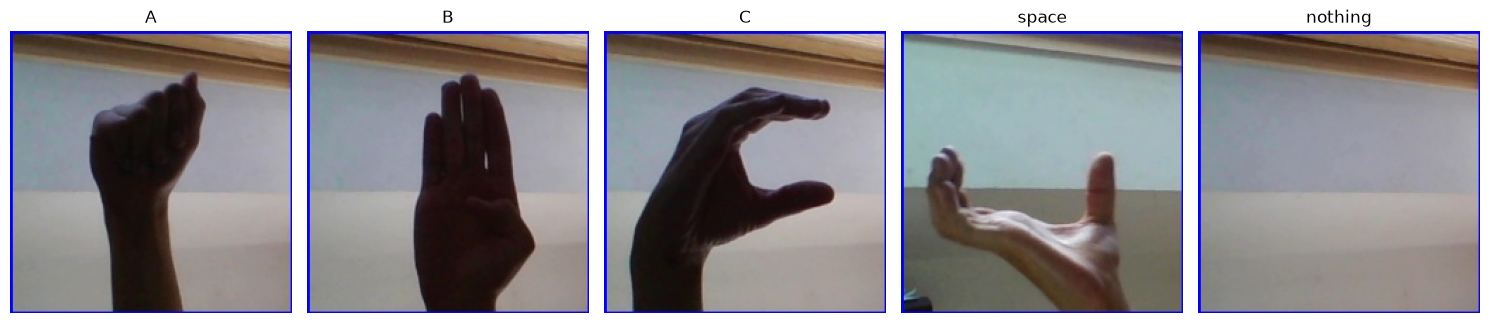

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

sample_classes = ["A", "B", "C", "space", "nothing"]

plt.figure(figsize=(15, 4))

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(train_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
sample_path = os.path.join(train_path, "A", os.listdir(os.path.join(train_path, "A"))[0])

image = Image.open(sample_path)

print("Image size:", image.size)
print("Image mode:", image.mode)


Image size: (200, 200)
Image mode: RGB


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [10]:
batch = next(train_generator)
print(type(batch))
print(len(batch))
print(batch[0].shape)
print(batch[1].shape)

<class 'tuple'>
2
(32, 128, 128, 3)
(32, 29)


In [14]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout   

model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(29, activation='softmax')
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,308,381 (12.62 MB)

 Trainable params: 3,308,381 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1531s 702ms/step - accuracy: 0.8211 - loss: 0.5933 - val_accuracy: 0.6136 - val_loss: 1.6498
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 759s 349ms/step - accuracy: 0.9803 - loss: 0.0627 - val_accuracy: 0.6862 - val_loss: 1.3069
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2729s 1s/step - accuracy: 0.9870 - loss: 0.0447 - val_accuracy: 0.7237 - val_loss: 1.3608
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 735s 338ms/step - accuracy: 0.9913 - loss: 0.0279 - val_accuracy: 0.7060 - val_loss: 1.6781
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1753s 806ms/step - accuracy: 0.9930 - loss: 0.0230 - val_accuracy: 0.7136 - val_loss: 1.7316
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 795s 365ms/step - accuracy: 0.9939 - loss: 0.0220 - val_accuracy: 0.7255 - val_loss: 1.3402
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 752s 346ms/step - accuracy: 0.9949 - loss: 0.0188 - val_accuracy: 0.7378 - val_loss: 1.6188
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 842s 387ms/step - ac

In [19]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9964080452919006
Final Validation Accuracy: 0.6925861835479736
Final Training Loss: 0.014852993190288544
Final Validation Loss: 2.5396409034729004


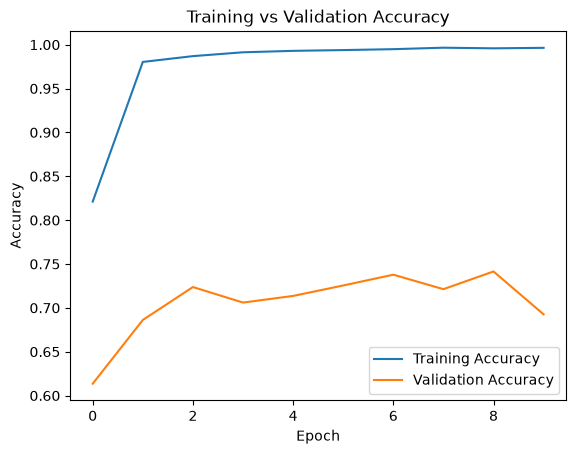

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

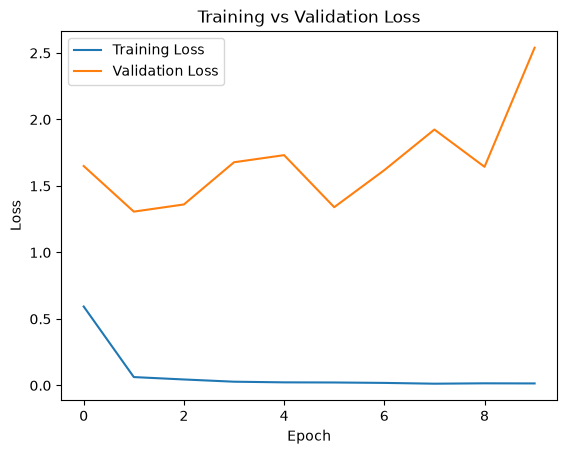

In [21]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [23]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(29, activation="softmax")
])

In [29]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [30]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2744s 1s/step - accuracy: 0.4297 - loss: 1.8276 - val_accuracy: 0.6315 - val_loss: 1.1712
Epoch 2/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1350s 621ms/step - accuracy: 0.7150 - loss: 0.8267 - val_accuracy: 0.7318 - val_loss: 0.8099
Epoch 3/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1597s 734ms/step - accuracy: 0.7973 - loss: 0.5777 - val_accuracy: 0.7886 - val_loss: 0.6366
Epoch 4/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1302s 598ms/step - accuracy: 0.8495 - loss: 0.4384 - val_accuracy: 0.8170 - val_loss: 0.7143
Epoch 5/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1075s 494ms/step - accuracy: 0.8763 - loss: 0.3553 - val_accuracy: 0.8321 - val_loss: 0.5861
Epoch 6/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1081s 497ms/step - accuracy: 0.8959 - loss: 0.3035 - val_accuracy: 0.8347 - val_loss: 0.5626
Epoch 7/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 10183s 5s/step - accuracy: 0.9081 - loss: 0.2657 - val_accuracy: 0.8301 - val_loss: 0.6260
Epoch 8/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2471s 1s/step - ac

In [31]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

544/544 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - accuracy: 0.8633 - loss: 0.4636
Validation Loss: 0.46359768509864807
Validation Accuracy: 0.8633333444595337


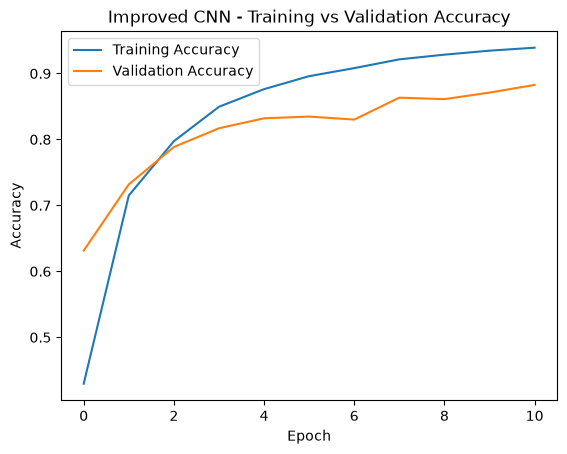

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN - Training vs Validation Accuracy")
plt.legend()

plt.show()

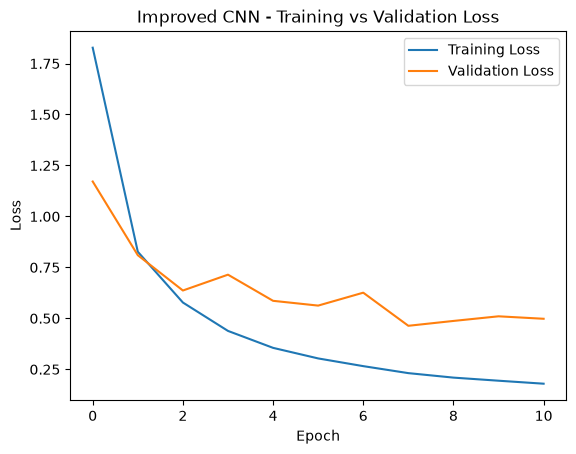

In [33]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN - Training vs Validation Loss")
plt.legend()

plt.show()

In [34]:
import os

models_folder = r"C:\Users\Admin\OneDrive\Desktop\AIMLFinalProject\models"

os.makedirs(models_folder, exist_ok=True)

model.save(
    r"C:\Users\Admin\OneDrive\Desktop\AIMLFinalProject\models\improved_sign_language_cnn.keras"
)

In [35]:
test_image_path = os.path.join(
    dataset_path,
    "asl_alphabet_test",
    "asl_alphabet_test",
    "A_test.jpg"
)

print(test_image_path)

C:\Users\Admin\OneDrive\Desktop\AIMLFinalProject\final_project_sign_dataset\asl_alphabet_test\asl_alphabet_test\A_test.jpg


In [36]:
from tensorflow.keras.utils import load_img

img = load_img(
    test_image_path,
    target_size=(128, 128)
)

In [37]:
print(img.size)
print(img.mode)

(128, 128)
RGB


In [38]:
from tensorflow.keras.utils import img_to_array

img_array = img_to_array(img)

print(img.size)
print(img.mode)

(128, 128)
RGB


In [40]:
print(img_array.shape)
img_array = img_array / 255.0

import numpy as np

img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(128, 128, 3)
(1, 128, 128, 3)


In [42]:
prediction = model.predict(img_array)

print(prediction)
predicted_index = np.argmax(prediction)

print(predicted_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[[0.01983996 0.01140846 0.00643273 0.00321657 0.01876679 0.00109465
  0.01410866 0.0114064  0.02637321 0.01509006 0.00571051 0.00622921
  0.01529622 0.0183361  0.01081165 0.00947222 0.00604248 0.01696681
  0.0748624  0.01335216 0.03990545 0.01946483 0.00518813 0.03959243
  0.03258626 0.01704545 0.025851   0.46555063 0.04999854]]
27


In [43]:
print(train_generator.class_indices)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


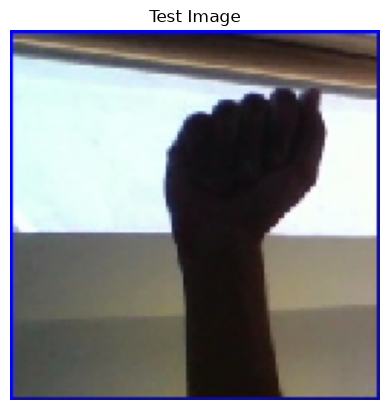

In [44]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Test Image")
plt.axis("off")
plt.show()

In [45]:
test_image_path = os.path.join(
    dataset_path,
    "asl_alphabet_test",
    "asl_alphabet_test",
    "B_test.jpg"
)

In [46]:
img = load_img(test_image_path, target_size=(128, 128))

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted index:", predicted_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted index: 1


In [47]:
class_names = {value: key for key, value in train_generator.class_indices.items()}

print(class_names)
predicted_class = class_names[predicted_index]

print("Predicted Sign:", predicted_class)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z', 26: 'del', 27: 'nothing', 28: 'space'}
Predicted Sign: B


In [48]:
def predict_sign(image_path):

    img = load_img(image_path, target_size=(128, 128))

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = np.max(prediction) * 100

    print("Predicted Sign:", predicted_class)
    print("Confidence:", confidence)

In [49]:
predict_sign(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Sign: B
Confidence: 100.0


In [50]:
test_folder = os.path.join(
    dataset_path,
    "asl_alphabet_test",
    "asl_alphabet_test"
)

test_images = os.listdir(test_folder)

print(test_images)
print("Number of test images:", len(test_images))

['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg', 'F_test.jpg', 'G_test.jpg', 'H_test.jpg', 'I_test.jpg', 'J_test.jpg', 'K_test.jpg', 'L_test.jpg', 'M_test.jpg', 'nothing_test.jpg', 'N_test.jpg', 'O_test.jpg', 'P_test.jpg', 'Q_test.jpg', 'R_test.jpg', 'space_test.jpg', 'S_test.jpg', 'T_test.jpg', 'U_test.jpg', 'V_test.jpg', 'W_test.jpg', 'X_test.jpg', 'Y_test.jpg', 'Z_test.jpg']
Number of test images: 28


In [57]:
# Random checking

test_image_path = os.path.join(
    test_folder,
    "H_test.jpg"
)

predict_sign(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Sign: H
Confidence: 99.99989
